# Experiment 1: Problem Formulation, Dataset Inspection and Baseline Modelling

**Dataset:** Titanic passengers  
**Target:** `Survived`  
**Experiment type:** Reproducible classification experiment

## Goal

Formulate the prediction problem, inspect dataset health, establish naive baselines, and determine whether a real machine-learning model is justified.

## 1. Predict — problem canvas

This is a **binary classification** task because the output is one of two known classes: survived (`1`) or did not survive (`0`). Passenger class, sex, age, family counts, fare, and embarkation port are candidate features. The success criterion is test accuracy materially above a majority-class baseline, with the test set kept isolated from all training decisions.

Before looking at the label distribution, a reasonable naive guess is that always predicting “did not survive” will be correct for roughly **60%** of passengers. The primary baseline is therefore `DummyClassifier(strategy="most_frequent")`; a stratified random baseline is used as a sensitivity check.

**Assumptions:** each row is one passenger; `Survived` is the target; identifier/high-cardinality columns (`PassengerId`, `Name`, `Ticket`, `Cabin`) are excluded from the initial feature set.

## 2. Load and inspect the dataset

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TEST_SIZE = 0.30

DATA_PATH = Path("Titanic-Dataset.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("Week 2") / "Titanic-Dataset.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("Titanic-Dataset.csv was not found in the current folder or Week 2.")

df = pd.read_csv(DATA_PATH)
print(f"Source: {DATA_PATH.resolve()}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())

Source: D:\Programming\SEM-5 ML labs\Week 2\Titanic-Dataset.csv
Shape: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 3. Dataset-health check

The audit checks duplicates, missing values, data types, constant columns, mixed Python types, and obviously impossible values. It also reports the cardinality of text columns.

In [3]:
duplicate_rows = int(df.duplicated().sum())
missing = df.isna().sum().sort_values(ascending=False)
constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
mixed_type_columns = {
    c: sorted({type(v).__name__ for v in df[c].dropna()})
    for c in df.columns if df[c].dropna().map(type).nunique() > 1
}
impossible = {
    "negative_age": int(df["Age"].lt(0).sum()),
    "age_over_120": int(df["Age"].gt(120).sum()),
    "negative_fare": int(df["Fare"].lt(0).sum()),
    "invalid_pclass": int((~df["Pclass"].isin([1, 2, 3])).sum()),
    "invalid_target": int((~df["Survived"].isin([0, 1])).sum()),
}

health = pd.DataFrame({
    "check": ["Duplicate rows", "Constant columns", "Mixed-type columns", "Impossible values"],
    "count": [duplicate_rows, len(constant_columns), len(mixed_type_columns), sum(impossible.values())],
    "details": [
        "exact duplicates",
        ", ".join(constant_columns) or "None",
        str(mixed_type_columns) if mixed_type_columns else "None",
        str(impossible),
    ],
})
display(health)
display(missing.rename("missing_count").to_frame().query("missing_count > 0"))

print("Text-column samples and cardinality:")
for c in df.select_dtypes(include="object").columns:
    print(f"- {c}: unique={df[c].nunique()}, sample={df[c].dropna().unique()[:5].tolist()}")

,check,count,details
0,Duplicate rows,0,exact duplicates
1,Constant columns,0,None
2,Mixed-type columns,0,None
3,Impossible values,0,"{'negative_age': 0, 'age_over_120': 0, 'negati..."


,missing_count
Cabin,687
Age,177
Embarked,2


Text-column samples and cardinality:
- Name: unique=891, sample=['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry']
- Sex: unique=2, sample=['male', 'female']
- Ticket: unique=681, sample=['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450']
- Cabin: unique=147, sample=['C85', 'C123', 'E46', 'G6', 'C103']
- Embarked: unique=3, sample=['S', 'C', 'Q']


## 4. Handle selected missing values

Missing `Cabin` values are filled with the column mode. Because `Embarked` has only two missing entries, those two rows are removed. `Cabin` remains excluded from modelling due to its high cardinality, so its full-dataset mode does not influence model fitting or evaluation.

In [4]:
df_clean = df.copy()

cabin_mode = df_clean["Cabin"].mode(dropna=True).iloc[0]
cabin_missing_before = int(df_clean["Cabin"].isna().sum())
df_clean["Cabin"] = df_clean["Cabin"].fillna(cabin_mode)

embarked_missing_before = int(df_clean["Embarked"].isna().sum())
df_clean = df_clean.dropna(subset=["Embarked"]).reset_index(drop=True)

assert df_clean["Cabin"].isna().sum() == 0
assert df_clean["Embarked"].isna().sum() == 0

print(f"Cabin mode used: {cabin_mode}")
print(f"Cabin values imputed: {cabin_missing_before}")
print(f"Rows dropped for missing Embarked: {embarked_missing_before}")
print(f"Cleaned dataset shape: {df_clean.shape}")
display(df_clean[["Cabin", "Embarked"]].isna().sum().rename("missing_after_cleaning").to_frame())

Cabin mode used: B96 B98
Cabin values imputed: 687
Rows dropped for missing Embarked: 2
Cleaned dataset shape: (889, 12)


,missing_after_cleaning
Cabin,0
Embarked,0


### Target distribution after cleaning

,proportion
Survived,
Did not survive,0.617548
Survived,0.382452


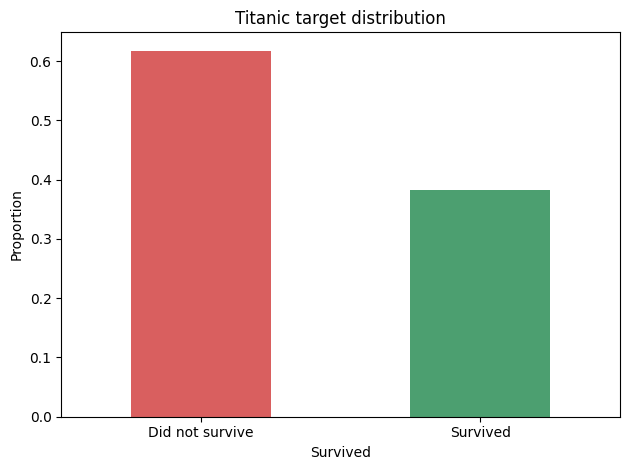

In [5]:
target_share = df_clean["Survived"].value_counts(normalize=True).sort_index()
display(target_share.rename(index={0: "Did not survive", 1: "Survived"}).to_frame("proportion"))
ax = target_share.rename(index={0: "Did not survive", 1: "Survived"}).plot.bar(
    color=["#d95f5f", "#4c9f70"], rot=0, title="Titanic target distribution"
)
ax.set_ylabel("Proportion")
plt.tight_layout()
plt.show()

## 5. Separate features and target; split into train and test sets

In [6]:
numeric_columns = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_columns = ["Sex", "Embarked"]
feature_columns = numeric_columns + categorical_columns
X = df_clean[feature_columns].copy()
y = df_clean["Survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Training survival rate: {y_train.mean():.3f} | Test survival rate: {y_test.mean():.3f}")

Training rows: 622 | Test rows: 267
Training survival rate: 0.383 | Test survival rate: 0.382


## 6. Build and evaluate dummy baselines

,test_accuracy
strategy,
most_frequent,0.618
stratified,0.513


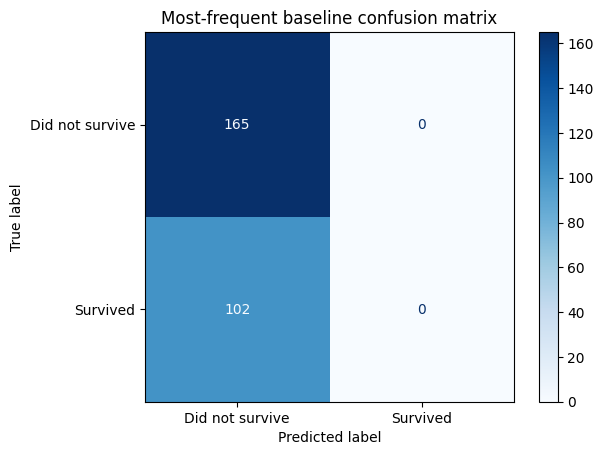

In [7]:
rows = []
predictions = {}
for strategy in ["most_frequent", "stratified"]:
    baseline = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    baseline.fit(X_train, y_train)
    predictions[strategy] = baseline.predict(X_test)
    rows.append({"strategy": strategy, "test_accuracy": accuracy_score(y_test, predictions[strategy])})

baseline_results = pd.DataFrame(rows).set_index("strategy")
display(baseline_results.style.format({"test_accuracy": "{:.3f}"}))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions["most_frequent"],
    display_labels=["Did not survive", "Survived"], cmap="Blues"
)
plt.title("Most-frequent baseline confusion matrix")
plt.show()

## 7. Plausible real-model comparison

This optional comparison uses only columns with no missing values: `Pclass`, `Sex`, `SibSp`, `Parch`, and `Fare`. Numeric features are scaled and `Sex` is one-hot encoded. No missing-value imputation is performed on the model-input columns, and all preprocessing is fitted on training data only.

In [8]:
# Use complete columns only; no imputation is performed.
model_numeric_columns = ["Pclass", "SibSp", "Parch", "Fare"]
model_categorical_columns = ["Sex"]
model_columns = model_numeric_columns + model_categorical_columns

assert not X_train[model_columns].isna().any().any()
assert not X_test[model_columns].isna().any().any()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), model_numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), model_categorical_columns),
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
model.fit(X_train[model_columns], y_train)
model_accuracy = accuracy_score(y_test, model.predict(X_test[model_columns]))
majority_accuracy = baseline_results.loc["most_frequent", "test_accuracy"]
print("Model-input imputation performed: No")
print(f"Most-frequent baseline accuracy: {majority_accuracy:.3f}")
print(f"Logistic-regression accuracy:    {model_accuracy:.3f}")
print(f"Absolute improvement:            {model_accuracy - majority_accuracy:+.3f}")

Model-input imputation performed: No
Most-frequent baseline accuracy: 0.618
Logistic-regression accuracy:    0.798
Absolute improvement:            +0.180


## 8. Observe, explain, modify, and reflect

In [9]:
guess = 0.60
stratified_accuracy = baseline_results.loc["stratified", "test_accuracy"]
print(f"The majority baseline scored {majority_accuracy:.3f}, {majority_accuracy - guess:+.3f} from the 0.60 guess.")
print("It gets the majority non-survival cases right but identifies no survivors, as the confusion matrix shows.")
print(f"Changing to the stratified strategy produced {stratified_accuracy:.3f} accuracy; it randomly follows class proportions.")
print(
    f"The leakage-free logistic model improved test accuracy by {model_accuracy - majority_accuracy:+.3f}. "
    "This gap shows that passenger attributes contain useful signal, so ML is justified, although accuracy "
    "should be supplemented by class-specific metrics in a consequential application."
)

The majority baseline scored 0.618, +0.018 from the 0.60 guess.
It gets the majority non-survival cases right but identifies no survivors, as the confusion matrix shows.
Changing to the stratified strategy produced 0.513 accuracy; it randomly follows class proportions.
The leakage-free logistic model improved test accuracy by +0.180. This gap shows that passenger attributes contain useful signal, so ML is justified, although accuracy should be supplemented by class-specific metrics in a consequential application.


## Takeaways

- Titanic survival is a binary-classification problem with a non-survival majority.
- Missing `Cabin` values are mode-imputed, while the two rows missing `Embarked` are dropped.
- The majority baseline is strong enough to expose misleading model claims but cannot identify survivors.
- A leakage-free real model provides the evidence needed to decide whether ML adds value.